## Reading in Datasets from Kaggle
#### Given the total size of the entire Kaggle Dataset (89GB) capturing 153M QUIC protocol flows *weeks_to_download* variable lets you select which weeks to download

In [1]:
import math

from sklearn.pipeline import FeatureUnion
from tensorflow.python.autograph.pyct.templates import replace

from data_acquisition import Data_acquisition

da = Data_acquisition()

# Specify which weeks to be downloaded
weeks_to_download = ['week_1', 'week_2', 'week_3', 'week_4']

da.download_datasets(weeks_to_download)

Downloading: cesnet-quic22/W-2022-44/7_Sun/flows-20221106.csv


100%|██████████| 1.67G/1.67G [04:52<00:00, 6.11MB/s]


Downloading: cesnet-quic22/W-2022-45/7_Sun/flows-20221113.csv


100%|██████████| 1.67G/1.67G [04:15<00:00, 7.01MB/s]


Downloading: cesnet-quic22/W-2022-46/7_Sun/flows-20221120.csv


100%|██████████| 1.54G/1.54G [04:41<00:00, 5.87MB/s]


Downloading: cesnet-quic22/W-2022-47/7_Sun/flows-20221127.csv


100%|██████████| 1.72G/1.72G [02:22<00:00, 13.0MB/s]

Download complete at for 4 weeks in ./dataset


### Data Exploration
#### Given the size only one day of data is explored to examine features and their distributions

In [2]:
import pandas as pd
week1_mon_df = pd.read_csv('./dataset/week_1/mon.csv')
week1_mon_df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: './dataset/week_1/mon.csv'

In [4]:
week1_mon_df.info()
week1_mon_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3576486 entries, 0 to 3576485
Data columns (total 30 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     int64  
 1   SRC_IP                 str    
 2   DST_IP                 str    
 3   DST_ASN                int64  
 4   SRC_PORT               int64  
 5   DST_PORT               int64  
 6   PROTOCOL               int64  
 7   QUIC_VERSION           int64  
 8   QUIC_SNI               str    
 9   QUIC_USERAGENT         str    
 10  TIME_FIRST             str    
 11  TIME_LAST              str    
 12  DURATION               float64
 13  BYTES                  int64  
 14  BYTES_REV              int64  
 15  PACKETS                int64  
 16  PACKETS_REV            int64  
 17  PPI_LEN                int64  
 18  PPI_DURATION           float64
 19  PPI_ROUNDTRIPS         int64  
 20  APP                    str    
 21  CATEGORY               str    
 22  FLOW_ENDREASON_IDLE    bool  

ID                             0
SRC_IP                         0
DST_IP                         0
DST_ASN                        0
SRC_PORT                       0
DST_PORT                       0
PROTOCOL                       0
QUIC_VERSION                   0
QUIC_SNI                       0
QUIC_USERAGENT           3568380
TIME_FIRST                     0
TIME_LAST                      0
DURATION                       0
BYTES                          0
BYTES_REV                      0
PACKETS                        0
PACKETS_REV                    0
PPI_LEN                        0
PPI_DURATION                   0
PPI_ROUNDTRIPS                 0
APP                            0
CATEGORY                       0
FLOW_ENDREASON_IDLE            0
FLOW_ENDREASON_ACTIVE          0
FLOW_ENDREASON_OTHER           0
PPI                            0
PHIST_SRC_SIZES                0
PHIST_DST_SIZES                0
PHIST_SRC_IPT                  0
PHIST_DST_IPT                  0
dtype: int

#### Class Distribution

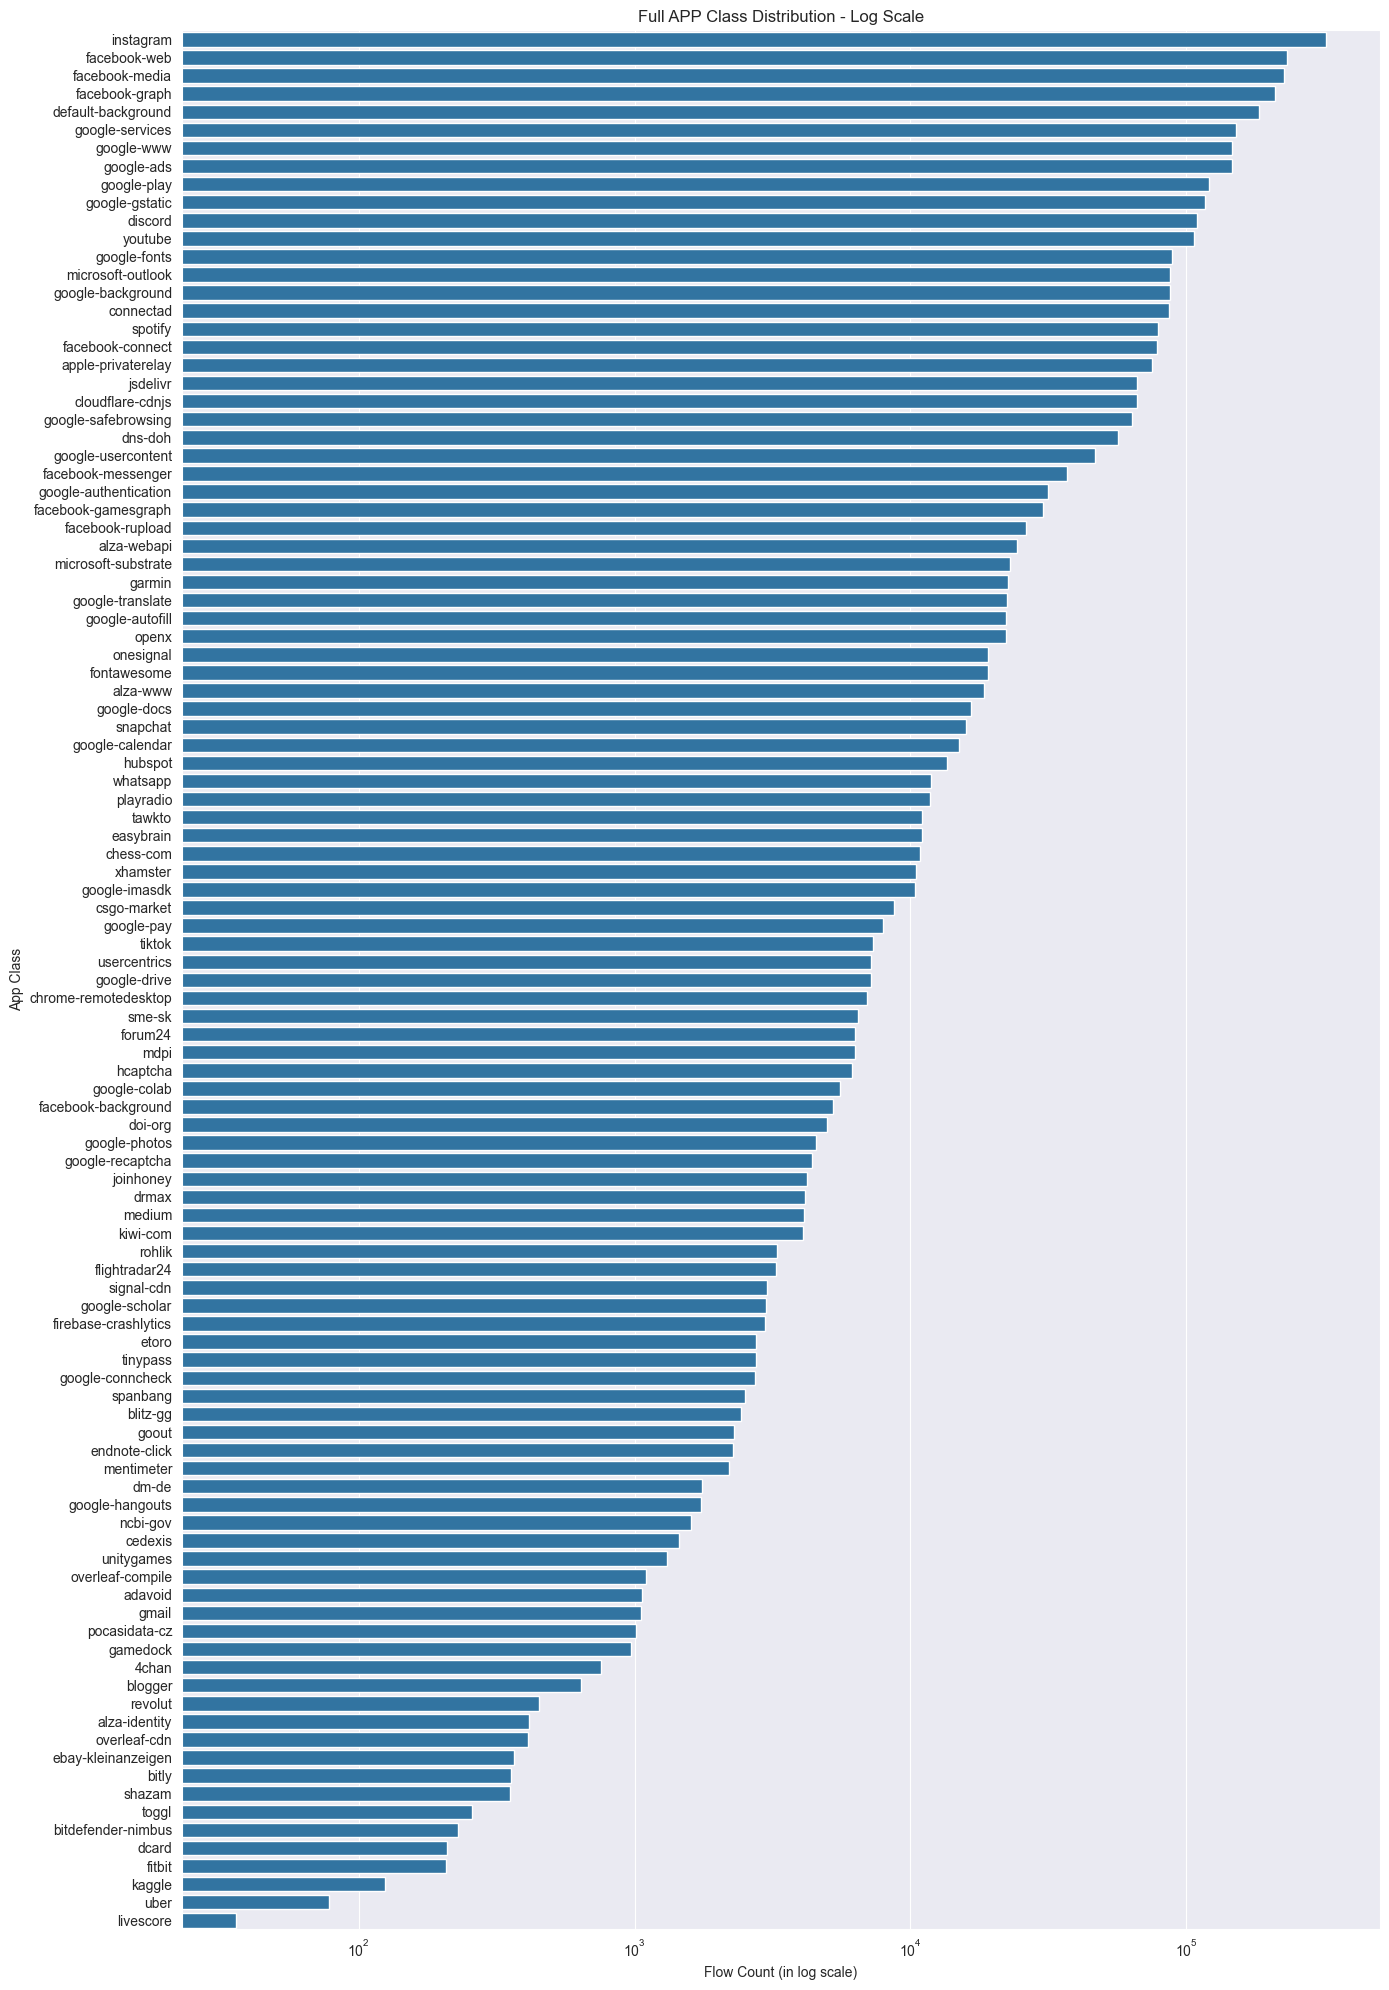

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

app_counts = week1_mon_df['APP'].value_counts()


plt.figure(figsize=(14, 20))
sns.barplot(x=app_counts.values, y=app_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Full APP Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

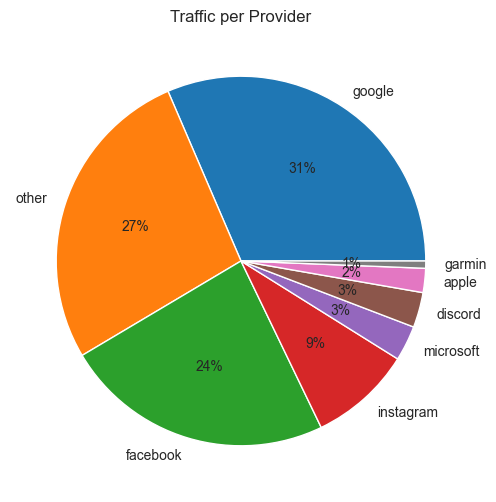

In [6]:
providers = ['google', 'microsoft', 'facebook','discord', 'instagram', 'apple', 'garmin']
def get_provider(app_name):
    app_lower = str(app_name).lower()
    for provider in providers:
        if provider in app_lower:
            return provider
    return 'other'

app_provider_percentage = (
    app_counts
    .groupby(get_provider)
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 6))
plt.pie(app_provider_percentage, labels=app_provider_percentage.index, autopct='%1.0f%%')
plt.title('Traffic per Provider')
plt.show()

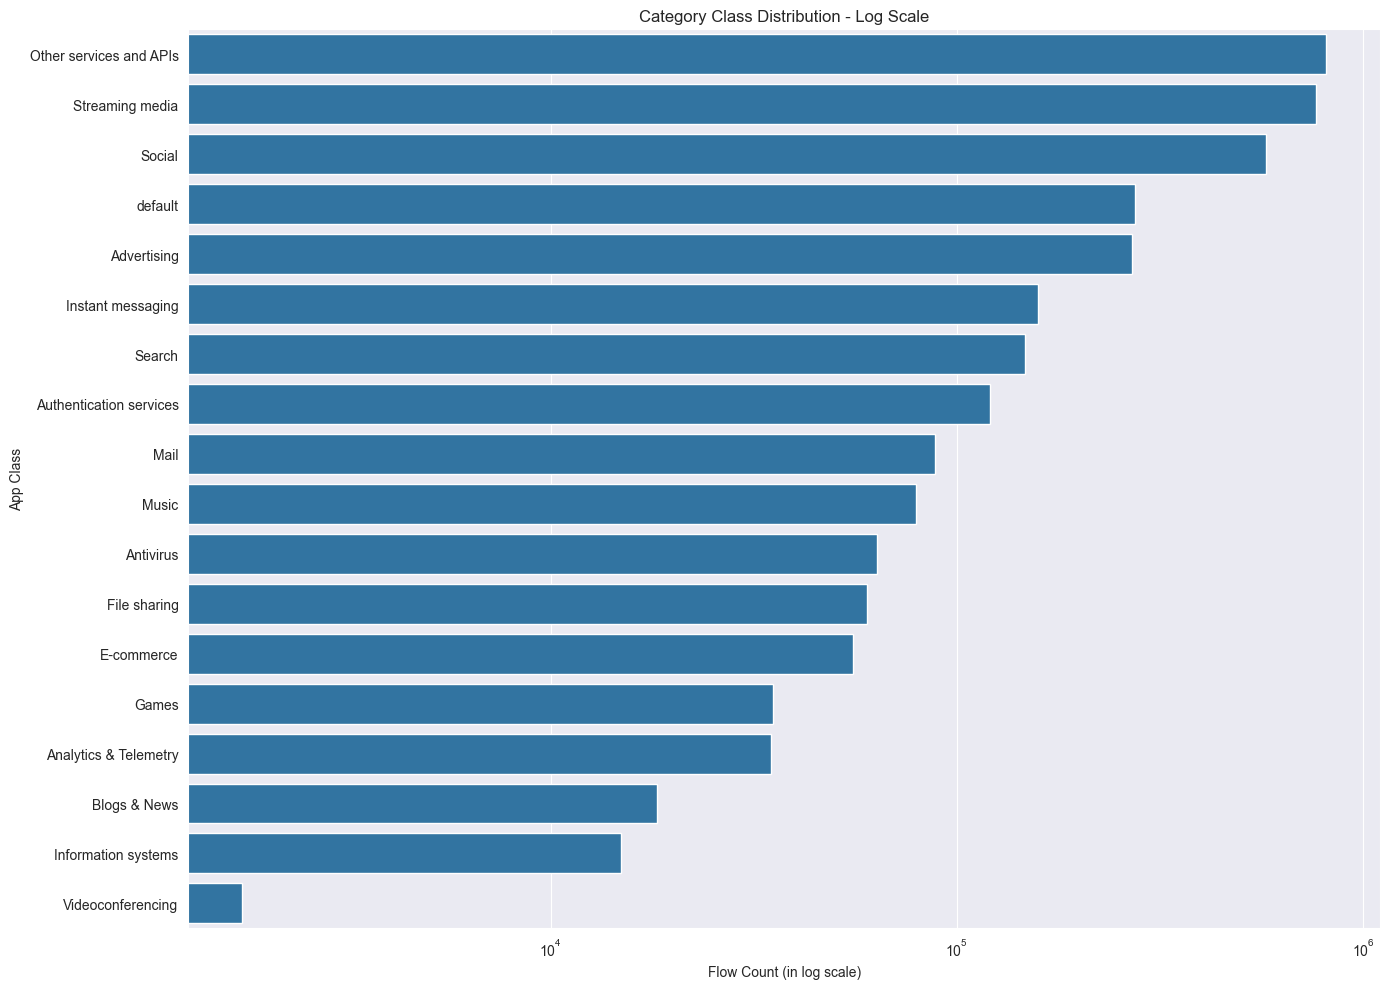

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = week1_mon_df['CATEGORY'].value_counts()


plt.figure(figsize=(14, 10))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Category Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

### Dropping Useless Columns prior to Storing in Database to reduce dataset size
#### Cols Dropped and Rational:
##### ID: Identifier column, no predictable signal.
##### SRC_IP/DST_IP: Dropped since although still present post ECH, vary across CDN's and load balancers. Model would memorise IP addresses rather.
##### DST_ASN: Derived from DST_IP and hence is proxy introducing data-leakage.
##### DST_PORT: Consistent, (443) is standard for QUIC.
##### PROTOCOL: Consistent all flows are QUIC-over-UDP.
##### QUIC_VERSION: Extracted from HelloClient Handshake.
##### QUIC_SNI: Extracted from HelloClient Handshake.
##### QUIC_USERAGENT: Derrived from HelloClient Handshake and lots of nulls.
###
#### Cols used for labels
##### APP: Application used (Fine-grained Label)
##### CATEGORY: Type of traffic (Generic Label)

In [1]:
# Drops columns and converts and replaces .csv files with .parquet to increase efficiency and decrease storage requirements
import json

cols_to_drop = []

cols_to_drop= ['ID', 'SRC_IP', 'DST_IP', 'DST_ASN', 'SRC_PORT', 'DST_PORT', 'PROTOCOL', 'QUIC_VERSION', 'QUIC_SNI', 'QUIC_USERAGENT']
with open('./config.json', 'w') as f:
    json.dump({'cols_to_drop': cols_to_drop}, f, indent=4)

# Ran as script due to multiprocessing
!python preprocessing.py

### Counting quantity of flows correlating to each 'APP' class in week_1 to establish a suitable maximum and minimum for data sampling
##### max_sampling: Maximum number of unique flows per class allowed in dataset.
##### min_sampling: Minimum flows required for a class to be retained in the dataset. Classes below this threshold are excluded from all splits.

In [2]:
import duckdb
import os

con = duckdb.connect()

week_path_dict = {
    'week_1': './dataset/week_1/*.parquet',
    'week_2': './dataset/week_2/*.parquet',
    'week_3': './dataset/week_3/*.parquet',
    'week_4': './dataset/week_4/*.parquet',
}

week_1_path = week_path_dict['week_1']

counts = con.execute(f"""
    SELECT APP, COUNT(*) as total_flows
    FROM read_parquet('{week_1_path}')
    GROUP BY APP
    ORDER BY total_flows ASC
""").df()

print(counts.to_string())
print(f"\nTotal classes: {len(counts)}")
print(f"Min flows in any class: {counts['total_flows'].min()}")
print(f"Max flows in any class: {counts['total_flows'].max()}")
print(f"Median flows per class: {counts['total_flows'].median()}")

# max_samples: Capped at 5000 — 10 classes fall below this naturally and contribute all available flows. Remaining 95 classes are downsampled to 5000.
max_samples = 5_000
# min_samples: Set to the minimum observed class count from Week 1 audit (uber, 1291). All 105 classes are retained — no classes are dropped.
min_samples = int(counts['total_flows'].min())

surviving_classes = con.execute(f"""
    SELECT APP
    FROM read_parquet('{week_1_path}')
    GROUP BY APP
    HAVING COUNT(*) >= {min_samples}
""").df()['APP'].tolist()

surviving_classes_sql = ', '.join(f"'{c}'" for c in surviving_classes)
print(f"\nSurviving classes: {len(surviving_classes)}")

                       APP  total_flows
0                     uber         1291
1                livescore         1871
2       ebay-kleinanzeigen         2270
3            alza-identity         2477
4                   fitbit         2637
5                    toggl         2694
6       bitdefender-nimbus         2808
7                   kaggle         3237
8                    dcard         4096
9             overleaf-cdn         4712
10           pocasidata-cz         5005
11                   bitly         5425
12                   4chan         5556
13                  shazam         6544
14                 adavoid         6652
15                 revolut         6880
16                 blogger         9017
17           endnote-click        11635
18                   gmail        12091
19        overleaf-compile        13059
20              signal-cdn        13357
21         google-hangouts        14387
22                   goout        14530
23                tinypass        15177


In [3]:
os.makedirs('./duckdb', exist_ok=True)

for k, v in week_path_dict.items():
    output_path = f'./duckdb/{k}_sampled.parquet'

    con.execute(f"""
        COPY (
            SELECT * EXCLUDE (rn)
            FROM (
                SELECT *,
                       ROW_NUMBER() OVER (
                           PARTITION BY APP
                           ORDER BY RANDOM()
                       ) as rn
                FROM read_parquet('{v}')
                WHERE APP IN ({surviving_classes_sql})
            )
            WHERE rn <= {max_samples}
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    result = con.execute(f"""
        SELECT APP, COUNT(*) as sampled_flows
        FROM read_parquet('{output_path}')
        GROUP BY APP
        ORDER BY sampled_flows ASC
    """).df()

    print(f"\n--- {k} ---")
    print(f"Classes retained: {len(result)}")
    print(f"Total rows: {result['sampled_flows'].sum()}")
    print(f"Min class: {result.iloc[0]['APP']} ({result.iloc[0]['sampled_flows']} flows)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_1 ---
Classes retained: 105
Total rows: 503093
Min class: uber (1291 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_2 ---
Classes retained: 105
Total rows: 510915
Min class: uber (1718 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_3 ---
Classes retained: 105
Total rows: 502781
Min class: livescore (731 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_4 ---
Classes retained: 105
Total rows: 511905
Min class: uber (1743 flows)


### Extracting nested data
##### PPI column contains three nested arrays per row (PPI_TIMES, PPI_DIRS, PPI_SIZES) consisting indices presenting 30 packets each. these are parsed and extracted into individual dataframe features.
##### PHIST columns (PHIST_SRC_SIZES etc...) have a single array per row consisting of 8 histogram bin counts. Each bin represents the number of packets falling within a specific size or inter-packet time range (on a log scale). These are parsed and extracted into individual dataframe features.

In [2]:
import pandas as pd
from feature_engineering import Feature_Engineering

ppi_pad_len = 30
phist_pad_len = 8

def pipeline_parse_cols(fe: Feature_Engineering, df: pd.DataFrame, ppi_pad_len: int, phist_pad_len: int):
    print('Parsing PPI cols')
    fe.parse_col('PPI', ['PPI_TIMES', 'PPI_DIRS', 'PPI_SIZES'])
    fe.parse_col_lists(ppi_pad_len)
    print('Parsing PHIST cols')
    fe.parse_col('PHIST_SRC_SIZES', ['PHIST_SRC_SIZES'])
    fe.parse_col('PHIST_DST_SIZES', ['PHIST_DST_SIZES'])
    fe.parse_col('PHIST_SRC_IPT', ['PHIST_SRC_IPT'])
    fe.parse_col('PHIST_DST_IPT', ['PHIST_DST_IPT'])
    fe.parse_col_lists(phist_pad_len)


#### Encoding and Scalings:
##### Data Exploration below reveals that numerical features are heavily skewed to the right indicating massive outlier ranges, therefore all numerical features were scaled using RobustScaler in order to not destroy these outliers

##### Label features were encoded using label encoder over one hot encoding given the number of additional columns that would need to be created. Dataframes are already massive with lots of features, adding more increases overfitting risk aswell as increased computation during model training.

Parsing PPI cols
Parsing PHIST cols


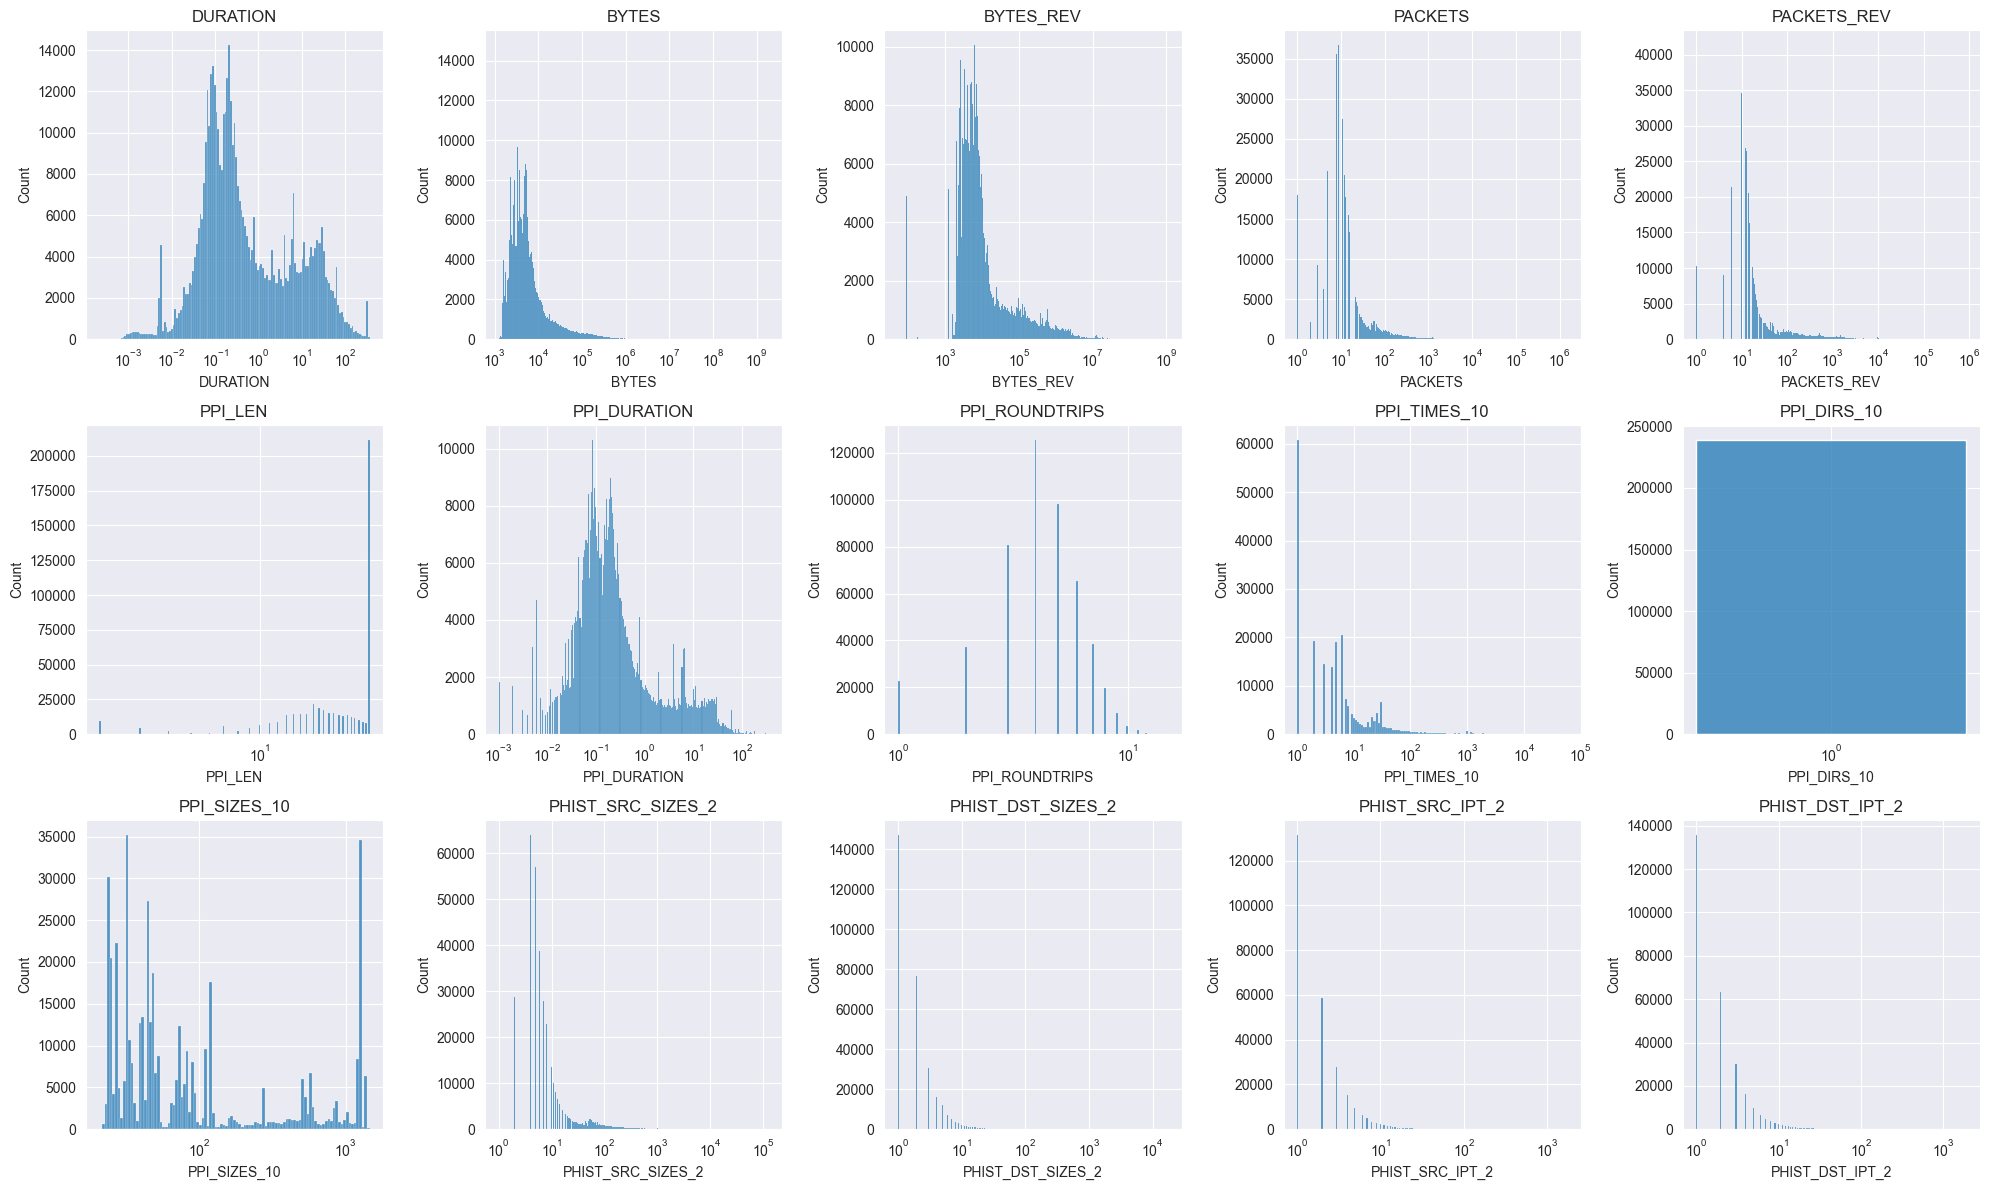

In [5]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engineering import Feature_Engineering

sample_week = pd.read_parquet('./duckdb/week_1_sampled.parquet')
fe = Feature_Engineering(sample_week)
pipeline_parse_cols(fe, sample_week, ppi_pad_len, phist_pad_len)
sample_week = fe.get_tabular_dataset()

ppi_sample_packet = math.floor(ppi_pad_len/3)
phist_sample_packet = math.floor(phist_pad_len/3)

numerical_cols = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS', f'PPI_TIMES_{ppi_sample_packet}', f'PPI_DIRS_{ppi_sample_packet}', f'PPI_SIZES_{ppi_sample_packet}', f'PHIST_SRC_SIZES_{phist_sample_packet}', f'PHIST_DST_SIZES_{phist_sample_packet}', f'PHIST_SRC_IPT_{phist_sample_packet}', f'PHIST_DST_IPT_{phist_sample_packet}']

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()  # now just a flat list of 15 slots

for i, col in enumerate(numerical_cols):
    sns.histplot(sample_week[col], kde=False, log_scale=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

##### Ostrates the scaling and encoding of each days dataset and saves them to ./tabular_dataset and ./sequential_dataset for ML models to use.

##### - tabular datasets contain all features + labels with PPI and PHIST array indices split into individual columns

##### - sequential datasets contain only PPI's + labels with each PPI as an array

In [3]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
import write_out
from feature_engineering import Feature_Engineering
import pandas as pd
import os

# Storing scaler and encoders for reverse_transform after
re = RobustScaler()
encoders_dict = {'label_encoder': {},
                 'RobustScaler': re}

for file in sorted(os.listdir('./duckdb')):
    if file.endswith('.parquet'):
        file_path = os.path.join('./duckdb', file)
        df = pd.read_parquet(file_path)
        print(f'{file}: {df.shape}')

        fe = Feature_Engineering(df)
        pipeline_parse_cols(fe, df, ppi_pad_len, phist_pad_len)

        is_week_1 =  "week_1" in file
        fe.perform_encode_and_scaling(encoders_dict, is_week_1)

        tabular_df = fe.get_tabular_dataset()
        write_out.write_out_tabular(tabular_df, file)


week_1_sampled.parquet: (503093, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_1_sampled.parquet
tabular_week_1_sampled.parquet: (503093, 135) saved to ./tabular_dataset/tabular_week_1_sampled.parquet
week_2_sampled.parquet: (510915, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_2_sampled.parquet
tabular_week_2_sampled.parquet: (510915, 135) saved to ./tabular_dataset/tabular_week_2_sampled.parquet
week_3_sampled.parquet: (502781, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_3_sampled.parquet
tabular_week_3_sampled.parquet: (502781, 135) saved to ./tabular_dataset/tabular_week_3_sampled.parquet
week_4_sampled.parquet: (511905, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust

### Datasets
- **Tabular no PPI** — Flow stats + PHIST only, no PPI features
- **Tabular with PPI** — Flow stats + PHIST + PPI summary features (`PPI_LEN`, `PPI_DURATION`, `PPI_ROUNDTRIPS`)
- **Sequential PPI only** — Raw PPI sequences only in sequential format

In [16]:
tab_training_path = './tabular_dataset/tabular_week_1_sampled.parquet'
training_df = pd.read_parquet(tab_training_path)

flow_features = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV']
endreason_features = ['FLOW_ENDREASON_IDLE', 'FLOW_ENDREASON_ACTIVE', 'FLOW_ENDREASON_OTHER']
phist_features = [col for col in training_df if col.startswith('PHIST_')]
ppi_summary_features = ['PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS']
ppi_sequence_features = [col for col in training_df if col.startswith('PPI_') and col not in ppi_summary_features]

# Tabular no PPI Dataframe
tab_no_ppi = training_df[flow_features + phist_features + endreason_features]
print('Tabular no PPI Dataset Columns: ' + str(tab_no_ppi.columns))

# Tabular with PPI Dataframe
tab_with_ppi = training_df[flow_features + phist_features + endreason_features + ppi_summary_features]
print('Tabular with PPI Dataset Columns: ' + str(tab_with_ppi.columns))

# Sequential PPI only Dataframe
ppi_seq_only = training_df[ppi_summary_features + ppi_sequence_features]
print('PPI Sequential Only Dataset Columns: ' + str(ppi_seq_only.columns))

Tabular no PPI Dataset Columns: Index(['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV',
       'PHIST_SRC_SIZES_0', 'PHIST_SRC_SIZES_1', 'PHIST_SRC_SIZES_2',
       'PHIST_SRC_SIZES_3', 'PHIST_SRC_SIZES_4', 'PHIST_SRC_SIZES_5',
       'PHIST_SRC_SIZES_6', 'PHIST_SRC_SIZES_7', 'PHIST_DST_SIZES_0',
       'PHIST_DST_SIZES_1', 'PHIST_DST_SIZES_2', 'PHIST_DST_SIZES_3',
       'PHIST_DST_SIZES_4', 'PHIST_DST_SIZES_5', 'PHIST_DST_SIZES_6',
       'PHIST_DST_SIZES_7', 'PHIST_SRC_IPT_0', 'PHIST_SRC_IPT_1',
       'PHIST_SRC_IPT_2', 'PHIST_SRC_IPT_3', 'PHIST_SRC_IPT_4',
       'PHIST_SRC_IPT_5', 'PHIST_SRC_IPT_6', 'PHIST_SRC_IPT_7',
       'PHIST_DST_IPT_0', 'PHIST_DST_IPT_1', 'PHIST_DST_IPT_2',
       'PHIST_DST_IPT_3', 'PHIST_DST_IPT_4', 'PHIST_DST_IPT_5',
       'PHIST_DST_IPT_6', 'PHIST_DST_IPT_7', 'FLOW_ENDREASON_IDLE',
       'FLOW_ENDREASON_ACTIVE', 'FLOW_ENDREASON_OTHER'],
      dtype='str')
Tabular with PPI Dataset Columns: Index(['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS',

### Random Forest Classifier: Just Flow Features
- **DURATION**
- **BYTES**
- **BYTES_REV**
- **PACKETS**
- **PACKET_REV**
- **PHIST_SRC_SIZES / PHIST_DST_SIZES**
- **PHIST_SRC_IPT / PHIST_DST_IPT**
- **FLOW_ENDREASON_ACTIVE / FLOW_ENDREASON_OTHER / FLOW_ENDREASON_IDLE**

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report


y = training_df['APP']
X = tab_no_ppi

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Macro F1 — your primary metric
f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {f1:.4f}')

# Full breakdown per class
print(classification_report(y_test, y_pred, zero_division=0))


Macro F1: 0.7652
              precision    recall  f1-score   support

           0       0.64      0.75      0.69      1500
           1       0.83      0.90      0.86      1500
           2       0.71      0.60      0.65       743
           3       0.80      0.80      0.80      1500
           4       0.56      0.60      0.58      1500
           5       0.97      0.99      0.98      1500
           6       0.87      0.89      0.88       843
           7       0.84      0.89      0.87      1500
           8       0.84      0.80      0.82      1500
           9       0.62      0.63      0.63      1500
          10       0.89      0.89      0.89      1500
          11       0.58      0.41      0.48      1500
          12       0.96      0.98      0.97      1500
          13       0.50      0.53      0.51      1500
          14       0.71      0.74      0.73      1500
          15       0.98      0.98      0.98      1500
          16       0.82      0.88      0.85      1229
          

### Random Forest Classifier: Just Flow Features
- **DURATION**
- **BYTES**
- **BYTES_REV**
- **PACKETS**
- **PACKET_REV**
- **PHIST_SRC_SIZES / PHIST_DST_SIZES**
- **PHIST_SRC_IPT / PHIST_DST_IPT**
- **FLOW_ENDREASON_ACTIVE / FLOW_ENDREASON_OTHER / FLOW_ENDREASON_IDLE**
- **PPI_LEN, PPI_DURATION, PPI_ROUNDTRIP**

In [ ]:
y = training_df['APP']
X = tab_with_ppi

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Macro F1 — your primary metric
f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {f1:.4f}')

# Full breakdown per class
print(classification_report(y_test, y_pred, zero_division=0))